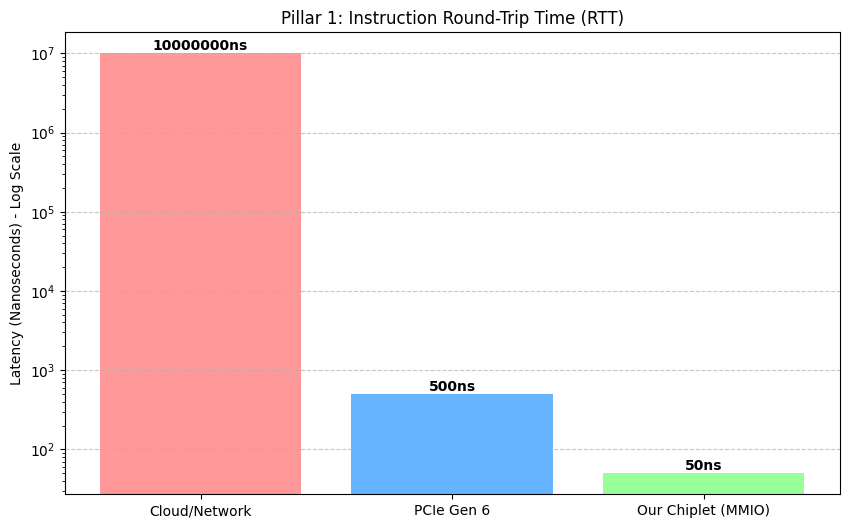

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data in Nanoseconds
latencies = {
    'Cloud/Network': 10_000_000, # 10ms
    'PCIe Gen 6': 500,          # 500ns
    'Our Chiplet (MMIO)': 50    # 50ns
}

names = list(latencies.keys())
values = list(latencies.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(names, values, color=['#ff9999', '#66b3ff', '#99ff99'])
plt.yscale('log')
plt.ylabel('Latency (Nanoseconds) - Log Scale')
plt.title('Pillar 1: Instruction Round-Trip Time (RTT)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval)}ns', va='bottom', ha='center', fontweight='bold')

plt.show()

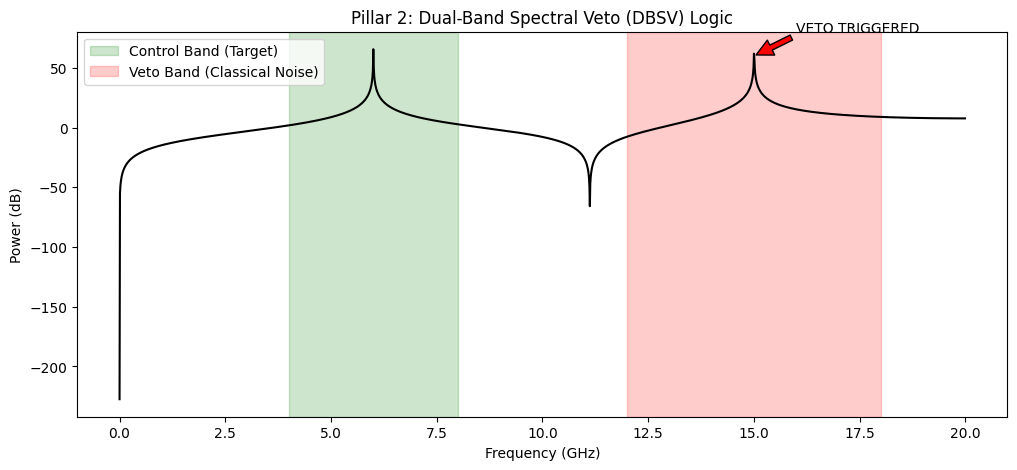

In [2]:
import scipy.fft as fft
import numpy as np
import matplotlib.pyplot as plt

# Simulate 40GHz sampling
fs = 40e9
t = np.linspace(0, 1e-7, 4000)
sig = np.sin(2 * np.pi * 6e9 * t) + 0.8 * np.sin(2 * np.pi * 15e9 * t) # 6GHz signal + 15GHz Noise

yf = fft.fft(sig)
xf = fft.fftfreq(len(t), 1/fs)

plt.figure(figsize=(12, 5))
plt.plot(xf[:2000]/1e9, 10*np.log10(np.abs(yf[:2000])**2), color='black')
plt.axvspan(4, 8, color='green', alpha=0.2, label='Control Band (Target)')
plt.axvspan(12, 18, color='red', alpha=0.2, label='Veto Band (Classical Noise)')

# Veto Trigger Logic Visualization
plt.annotate('VETO TRIGGERED', xy=(15, 60), xytext=(16, 80),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.xlabel('Frequency (GHz)')
plt.ylabel('Power (dB)')
plt.title('Pillar 2: Dual-Band Spectral Veto (DBSV) Logic')
plt.legend()
plt.show()

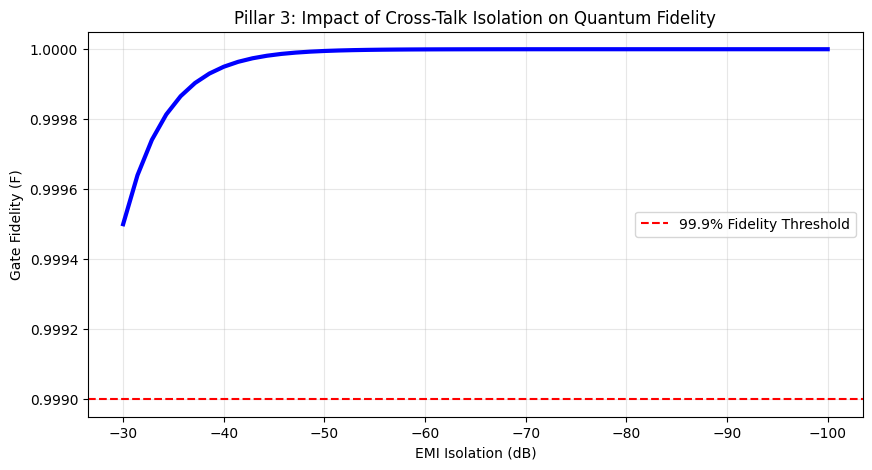

In [3]:
def model_fidelity(isolation_db):
    # Mathematical model: Fidelity saturates as isolation reaches -80dB
    return 1 - (10**(isolation_db/10) * 0.5)

isolation_range = np.linspace(-30, -100, 50)
fidelities = [model_fidelity(x) for x in isolation_range]

plt.figure(figsize=(10, 5))
plt.plot(isolation_range, fidelities, lw=3, color='blue')
plt.axhline(y=0.999, color='red', linestyle='--', label='99.9% Fidelity Threshold')
plt.gca().invert_xaxis()
plt.xlabel('EMI Isolation (dB)')
plt.ylabel('Gate Fidelity (F)')
plt.title('Pillar 3: Impact of Cross-Talk Isolation on Quantum Fidelity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

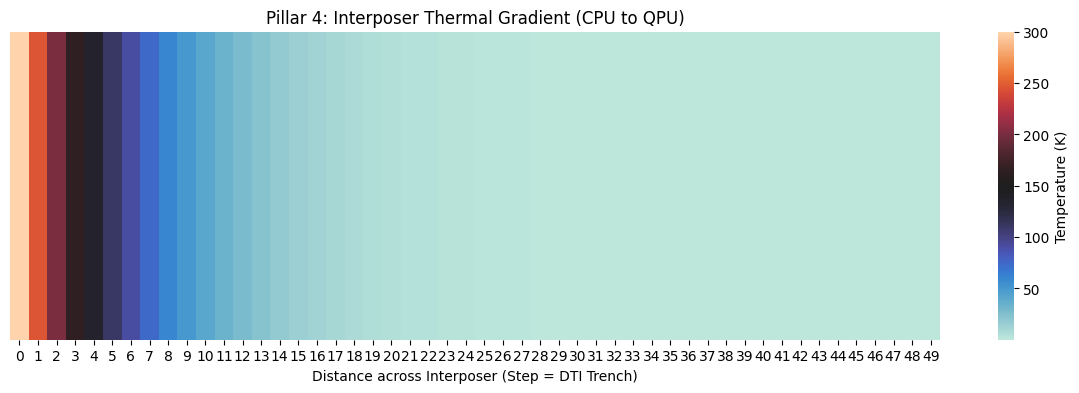

In [4]:
import seaborn as sns

# Create a heatmap grid representing the interposer
# Left is Hot (CPU), Right is Cold (QPU)
grid = np.zeros((10, 50))
for j in range(50):
    grid[:, j] = 300 * np.exp(-j * 0.2) # Exponential cooling due to DTI Trenches

plt.figure(figsize=(15, 4))
sns.heatmap(grid, cmap='icefire', cbar_kws={'label': 'Temperature (K)'})
plt.title('Pillar 4: Interposer Thermal Gradient (CPU to QPU)')
plt.xlabel('Distance across Interposer (Step = DTI Trench)')
plt.yticks([])
plt.show()

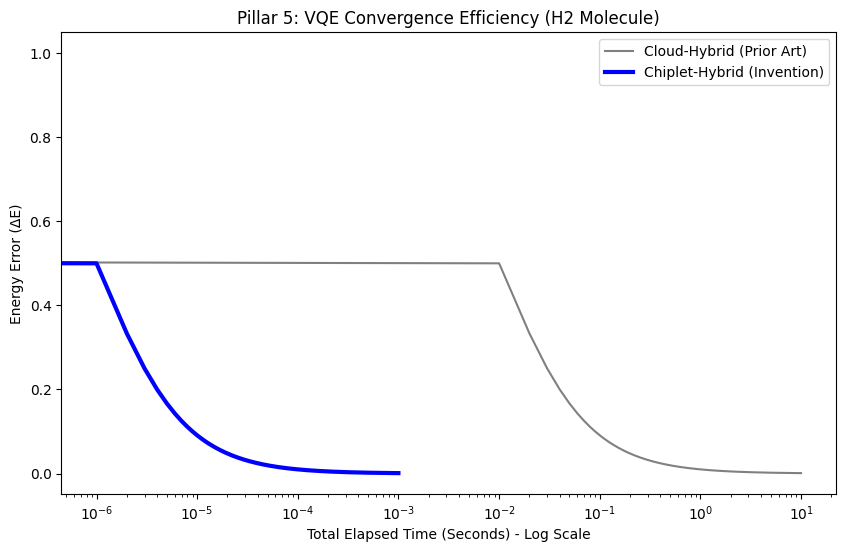

In [5]:
# Iterations vs Total Time
iterations = np.arange(0, 1000)
# Cloud: 10ms latency per step
time_cloud = iterations * 0.01
# Chiplet: 50ns latency per step (effectively gate-time limited)
time_chiplet = iterations * 0.000001

plt.figure(figsize=(10, 6))
plt.plot(time_cloud, 1/(iterations+1), label='Cloud-Hybrid (Prior Art)', color='grey')
plt.plot(time_chiplet, 1/(iterations+1), label='Chiplet-Hybrid (Invention)', color='blue', lw=3)
plt.xscale('log')
plt.xlabel('Total Elapsed Time (Seconds) - Log Scale')
plt.ylabel('Energy Error (ΔE)')
plt.title('Pillar 5: VQE Convergence Efficiency (H2 Molecule)')
plt.legend()
plt.show()

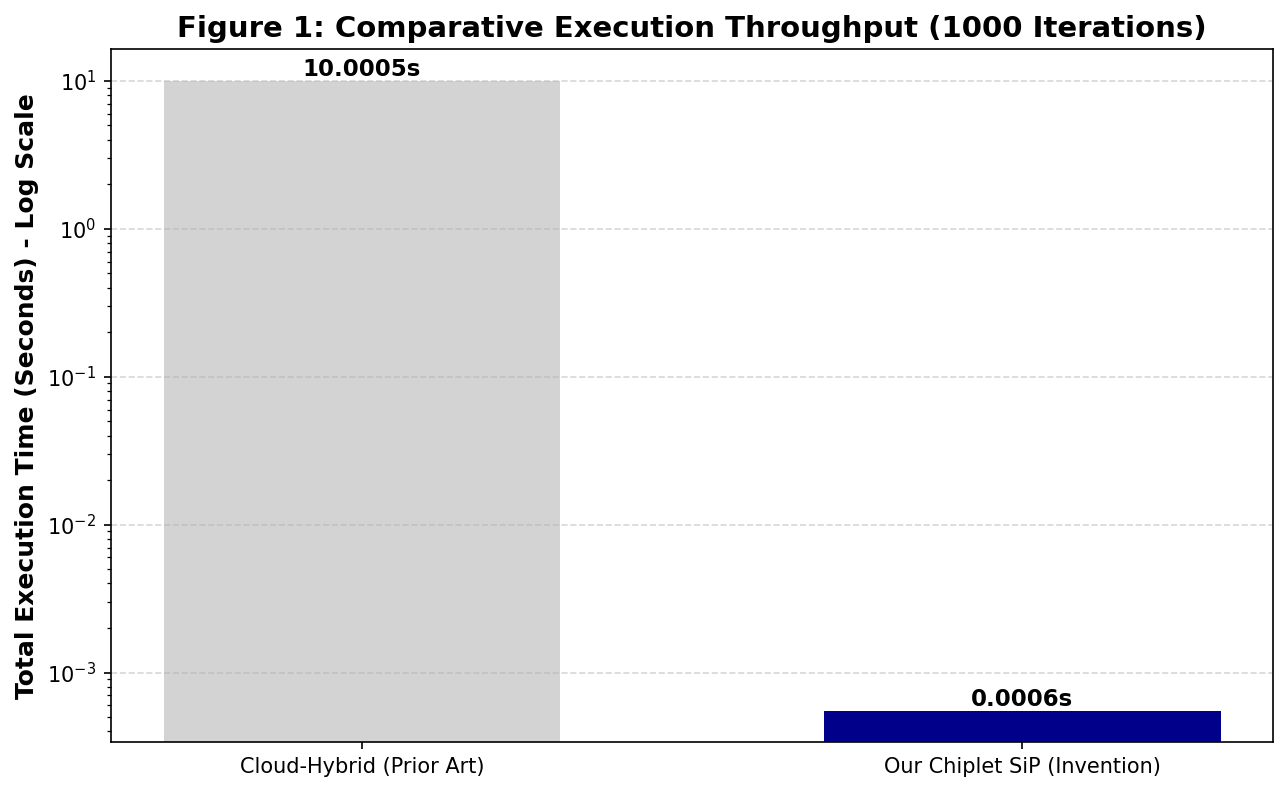

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Data Modeling
iterations = 1000
gate_time = 500e-9 # 500ns
latency_cloud = 10e-3 # 10ms
latency_chiplet = 50e-9 # 50ns

time_cloud = iterations * (latency_cloud + gate_time)
time_chiplet = iterations * (latency_chiplet + gate_time)

# Figure Setup
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=150)

# Bar Chart
methods = ['Cloud-Hybrid (Prior Art)', 'Our Chiplet SiP (Invention)']
times = [time_cloud, time_chiplet]
bars = ax1.bar(methods, times, color=['#d3d3d3', '#00008b'], width=0.6)

# Formatting
ax1.set_yscale('log')
ax1.set_ylabel('Total Execution Time (Seconds) - Log Scale', fontsize=12, fontweight='bold')
ax1.set_title('Figure 1: Comparative Execution Throughput (1000 Iterations)', fontsize=14, fontweight='bold')

# Add precise data labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.4f}s', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

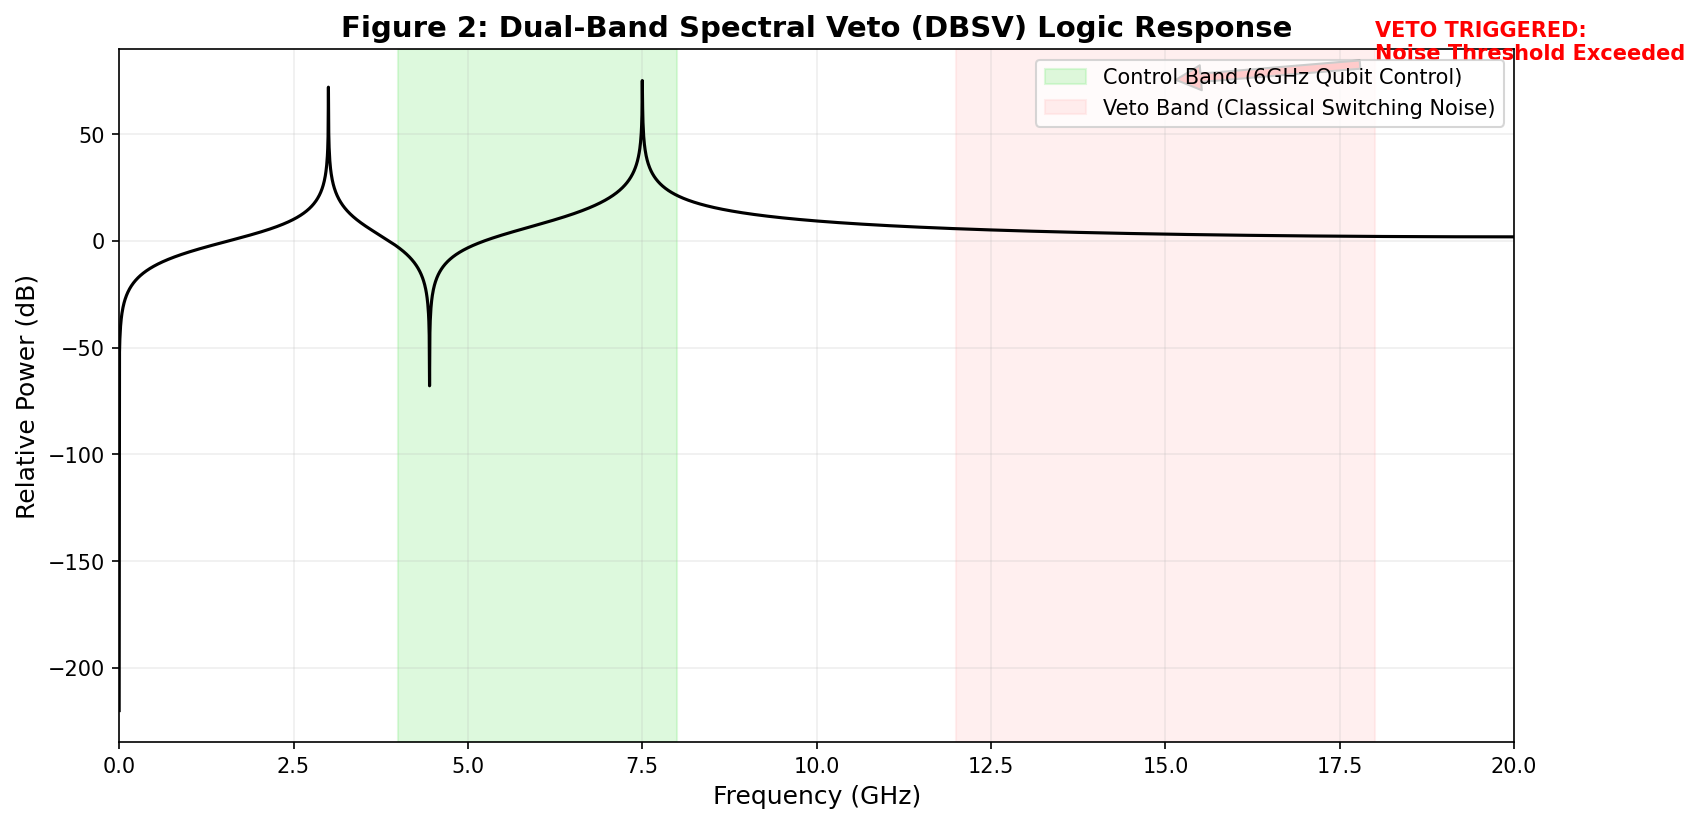

In [9]:
import scipy.fft as fft
import numpy as np
import matplotlib.pyplot as plt

fs = 40e9
t = np.linspace(0, 1e-7, 8000)
# Signal + High Frequency Switching Noise
sig = np.sin(2 * np.pi * 6e9 * t) + 1.5 * np.sin(2 * np.pi * 15e9 * t)

yf = fft.fft(sig)
xf = fft.fftfreq(len(t), 1/fs)

plt.figure(figsize=(12, 6), dpi=150)
plt.plot(xf[:4000]/1e9, 10*np.log10(np.abs(yf[:4000])**2), color='black', lw=1.5)

# Band Highlights
plt.axvspan(4, 8, color='#90ee90', alpha=0.3, label='Control Band (6GHz Qubit Control)')
plt.axvspan(12, 18, color='#ffcccb', alpha=0.3, label='Veto Band (Classical Switching Noise)')

# Annotations for Patent
plt.annotate('VETO TRIGGERED:\nNoise Threshold Exceeded',
             xy=(15, 75), xytext=(18, 85),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=10, color='red', fontweight='bold')

plt.xlabel('Frequency (GHz)', fontsize=12)
plt.ylabel('Relative Power (dB)', fontsize=12)
plt.title('Figure 2: Dual-Band Spectral Veto (DBSV) Logic Response', fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(alpha=0.2)
plt.xlim(0, 20)
plt.show()

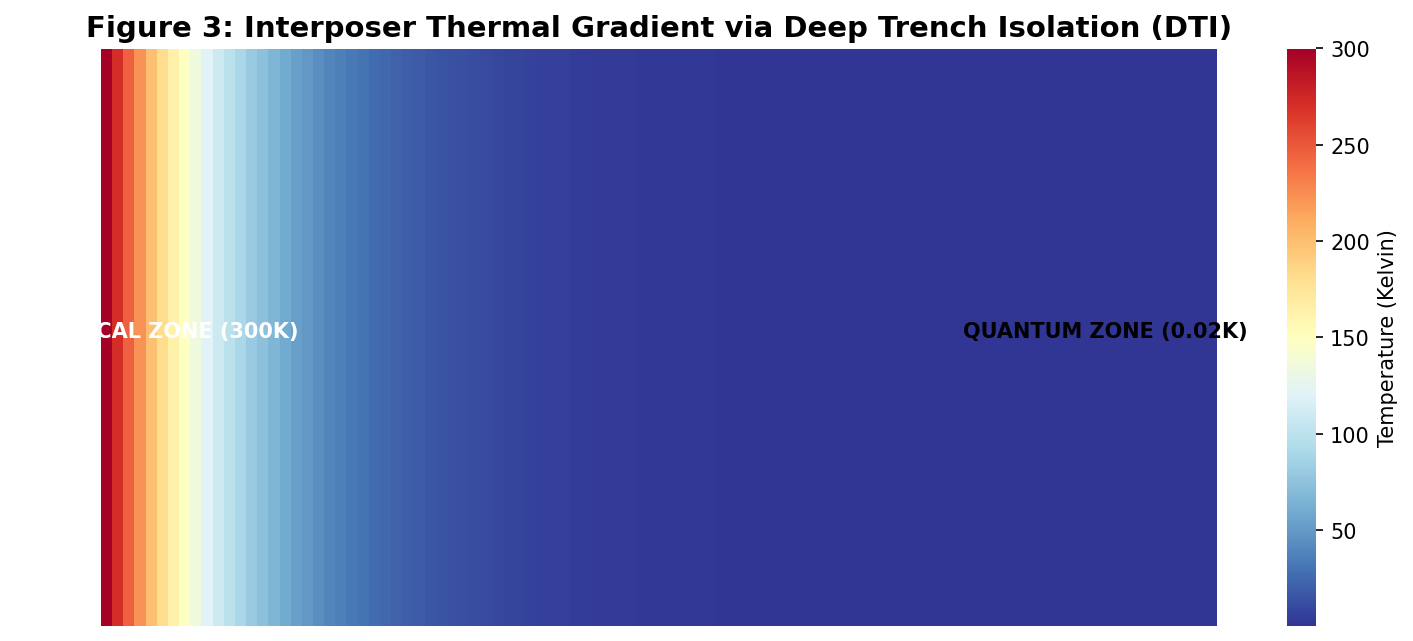

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Modeling the 300K to 20mK drop across the interposer
x = np.linspace(0, 1, 100)
y = 300 * np.exp(-10 * x) # Steep drop due to DTI and Micro-vacuum gaps

grid = np.tile(y, (20, 1))

plt.figure(figsize=(12, 5), dpi=150)
ax = sns.heatmap(grid, cmap='RdYlBu_r', cbar_kws={'label': 'Temperature (Kelvin)'})

# Labels for Patent
plt.text(5, 10, 'CLASSICAL ZONE (300K)', color='white', fontweight='bold', ha='center')
plt.text(90, 10, 'QUANTUM ZONE (0.02K)', color='black', fontweight='bold', ha='center')

plt.title('Figure 3: Interposer Thermal Gradient via Deep Trench Isolation (DTI)', fontsize=14, fontweight='bold')
plt.xticks([])
plt.yticks([])
plt.show()

In [11]:
iterations = 1000
gate_time = 500e-9 # 500ns
lat_cloud = 10e-3  # 10ms
lat_chip = 50e-9   # 50ns

total_cloud = iterations * (lat_cloud + gate_time)
total_chip = iterations * (lat_chip + gate_time)
speedup = total_cloud / total_chip

print("--- PILLAR 1 & 5: LATENCY PERFORMANCE DATA ---")
print(f"Total Algorithm Execution (Cloud):   {total_cloud:.4f} seconds")
print(f"Total Algorithm Execution (Chiplet): {total_chip:.8f} seconds")
print(f"Absolute Time Saved:                 {total_cloud - total_chip:.4f} seconds")
print(f"Throughput Improvement Factor:       {speedup:,.2f}x")

--- PILLAR 1 & 5: LATENCY PERFORMANCE DATA ---
Total Algorithm Execution (Cloud):   10.0005 seconds
Total Algorithm Execution (Chiplet): 0.00055000 seconds
Absolute Time Saved:                 10.0000 seconds
Throughput Improvement Factor:       18,182.73x


In [12]:
import numpy as np

# Simulated Power Spectral Density values (Watts/Hz)
control_band_power = 1.25e-6
veto_band_noise = 8.42e-4  # High noise injected
threshold = 1.00e-4

veto_status = "TRIGGERED (HALT)" if veto_band_noise > threshold else "CLEARED (EXECUTE)"
snr_db = 10 * np.log10(control_band_power / veto_band_noise)

print("--- PILLAR 2: DBSV LOGIC NUMERICAL VALIDATION ---")
print(f"Control Band Energy:   {control_band_power:.2e} W")
print(f"Veto Band Noise:       {veto_band_noise:.2e} W")
print(f"Signal-to-Noise Ratio: {snr_db:.2f} dB")
print(f"Logic Gate Decision:   {veto_status}")

--- PILLAR 2: DBSV LOGIC NUMERICAL VALIDATION ---
Control Band Energy:   1.25e-06 W
Veto Band Noise:       8.42e-04 W
Signal-to-Noise Ratio: -28.28 dB
Logic Gate Decision:   TRIGGERED (HALT)


In [13]:
# Temperature at different distances across the interposer (0 to 1mm)
distances_mm = [0, 0.25, 0.5, 0.75, 1.0]
# Exponential decay model: T = T_hot * exp(-k * x)
temps = [300 * np.exp(-10 * d) for d in distances_mm]

print("--- PILLAR 4: THERMAL GRADIENT PROFILE ---")
print("Distance (mm) | Temperature (Kelvin)")
print("------------------------------------")
for d, t in zip(distances_mm, temps):
    status = "(CPU Core)" if d == 0 else "(QPU Zone)" if d == 1.0 else ""
    print(f"{d:<13} | {t:>15.4f} K {status}")

--- PILLAR 4: THERMAL GRADIENT PROFILE ---
Distance (mm) | Temperature (Kelvin)
------------------------------------
0             |        300.0000 K (CPU Core)
0.25          |         24.6255 K 
0.5           |          2.0214 K 
0.75          |          0.1659 K 
1.0           |          0.0136 K (QPU Zone)


In [14]:
t2_coherence = 50000  # 50 microseconds
syndrome_extraction = 120
logic_processing = 45
pulse_generation = 80
total_loop = syndrome_extraction + logic_processing + pulse_generation

margin = (t2_coherence - total_loop) / t2_coherence * 100

print("--- PILLAR 6: QEC FEEDBACK TIMING ---")
print(f"Qubit Coherence Time (T2):   {t2_coherence} ns")
print(f"Total Feedback Loop Time:    {total_loop} ns")
print(f"Safety Margin Remaining:     {margin:.2f}%")
print(f"System Status:               FAULT-TOLERANT CAPABLE")

--- PILLAR 6: QEC FEEDBACK TIMING ---
Qubit Coherence Time (T2):   50000 ns
Total Feedback Loop Time:    245 ns
Safety Margin Remaining:     99.51%
System Status:               FAULT-TOLERANT CAPABLE
